![display relevant image here](path/url/to/image)
- Banner/header image

# Title
- Relevant to Data and Business Context

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


3.1 Basic data characteristics

In [18]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder,StandardScaler)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [26]:
# EDA Code Here - Create New Cells As Needed
df = pd.read_csv("financial_loan_data.csv")

df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [27]:
df.tail()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
19995,44,"$30,180.00",587,Employed,High School,19,24521,36,Married,3,...,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,0,55.0
19996,56,"$49,246.00",567,Employed,Associate,33,25818,36,Married,5,...,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,0,54.0
19997,44,"$48,958.00",645,Employed,Bachelor,20,37033,72,Married,3,...,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,0,45.0
19998,60,"$41,025.00",560,Employed,NaN,36,14760,72,NaN,3,...,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,0,59.0
19999,20,"$53,227.00",574,Employed,Associate,0,32055,48,Married,0,...,4435.583333,0.853801,5,41372,0.240055,0.242693,1049.830407,0.298006,0,59.0


In [28]:
#Dataset shape
print(f"Rows:{df.shape[0]} , Columns: {df.shape[1]}")

Rows:20000 , Columns: 35


In [22]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [23]:
#summary statistics
df.describe()

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,0.993000,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,0.986965,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,0.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,1.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,2.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,7.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


3.2: Examine Distributions of All Features and Target Variables

In [43]:
#first cleaning the AnualIncome
df['AnnualIncome'] = df['AnnualIncome'].replace(',', '').astype(float)

In [44]:
# Separate features by type for targeted plotting
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

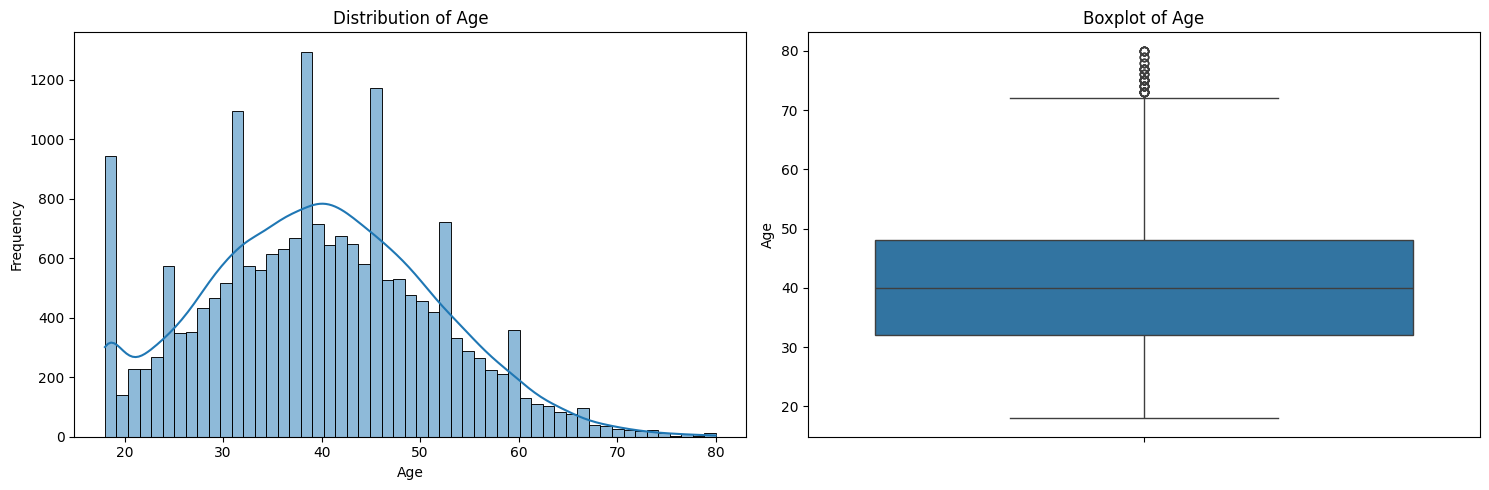

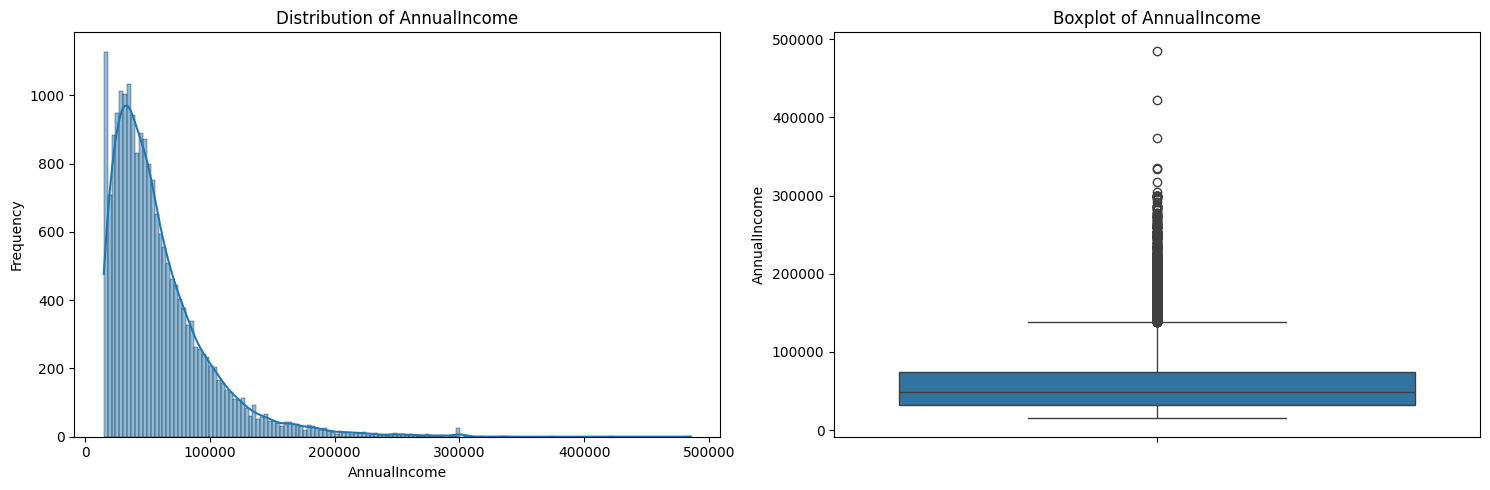

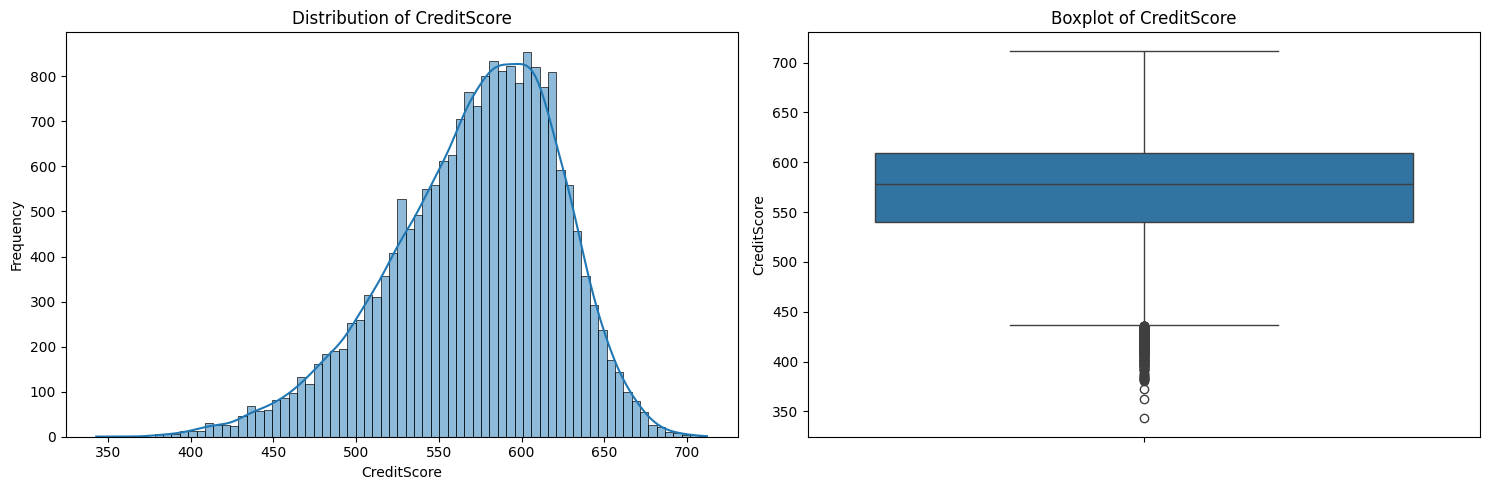

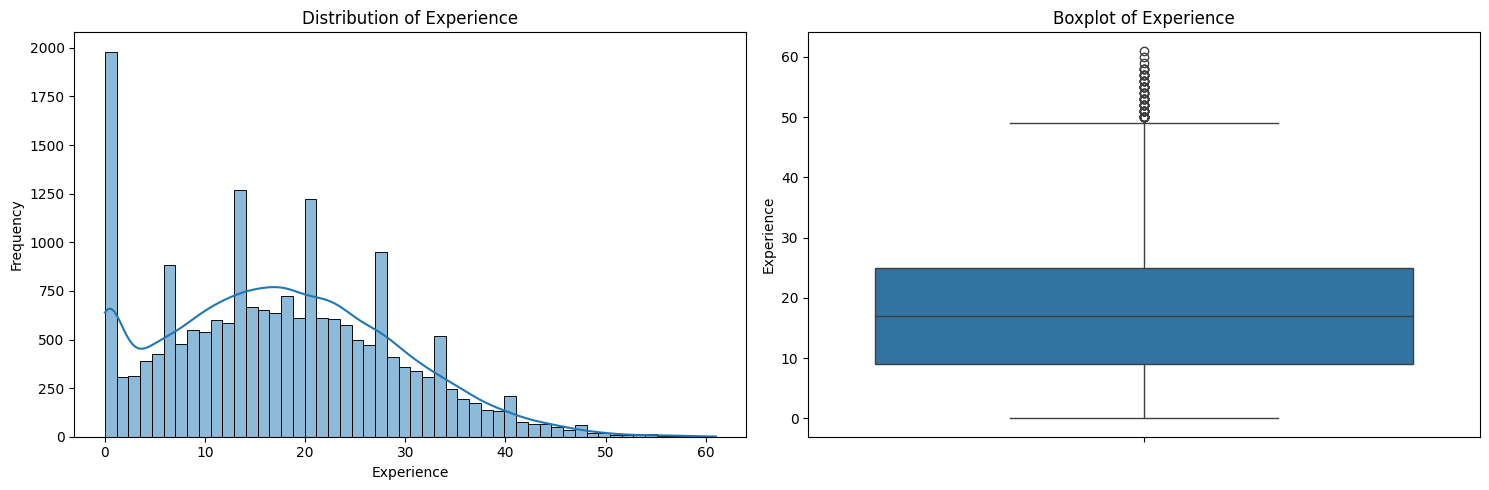

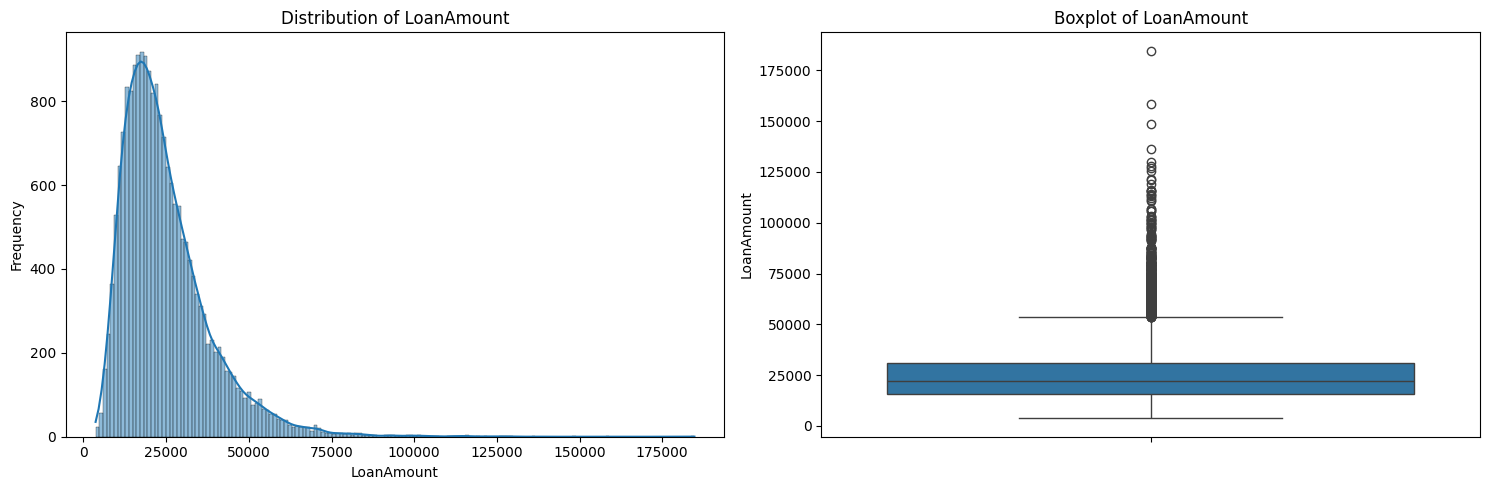

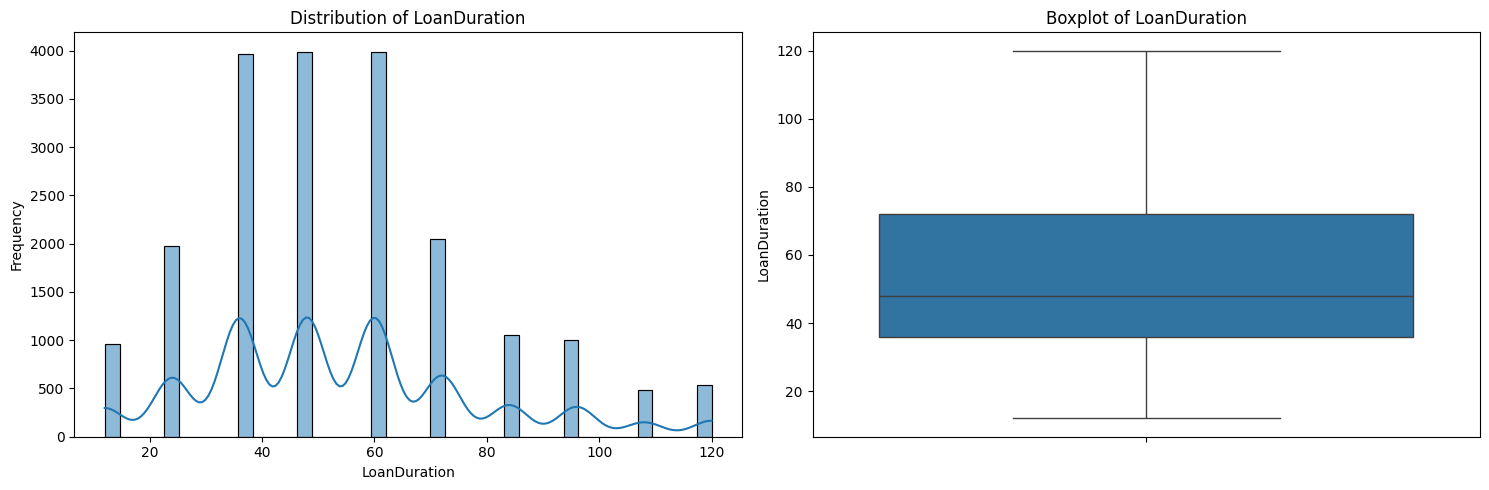

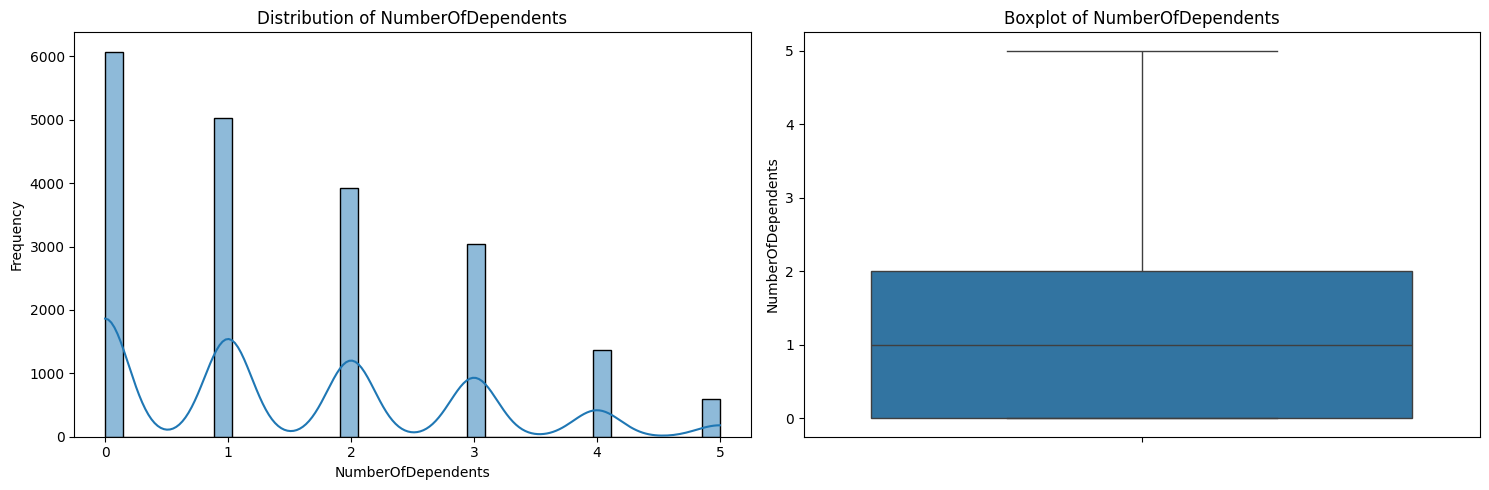

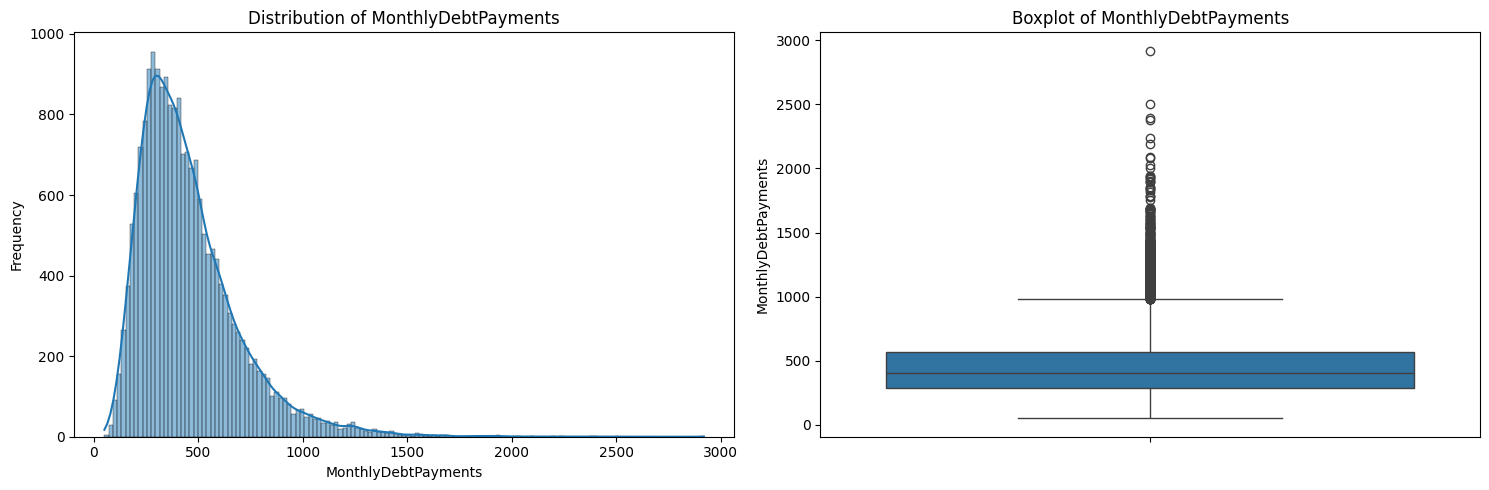

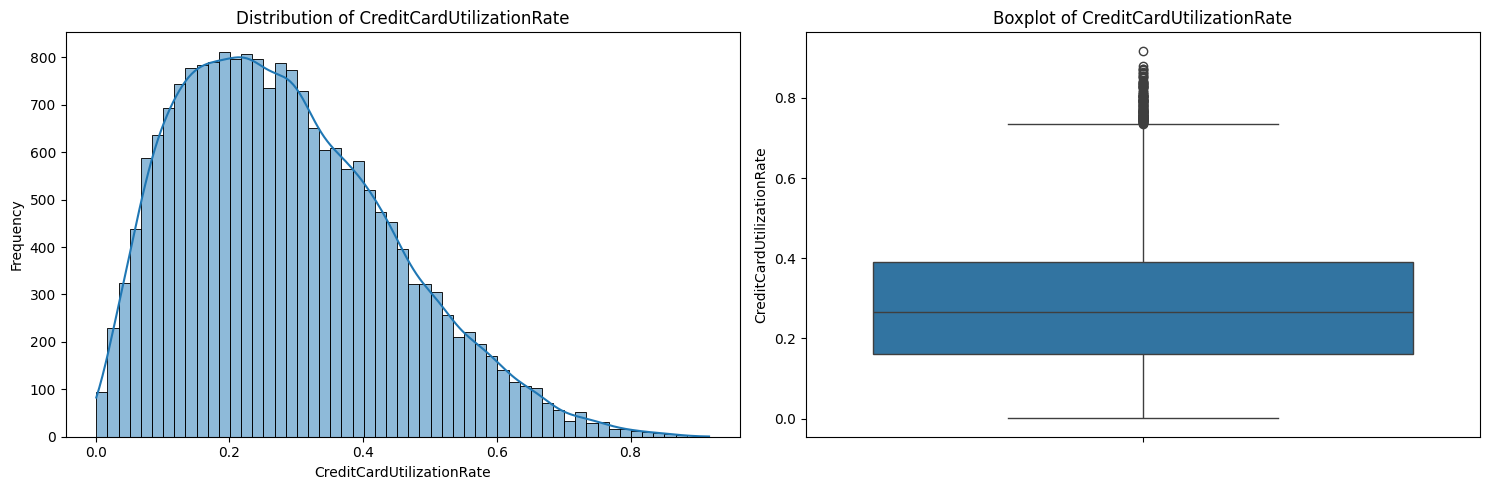

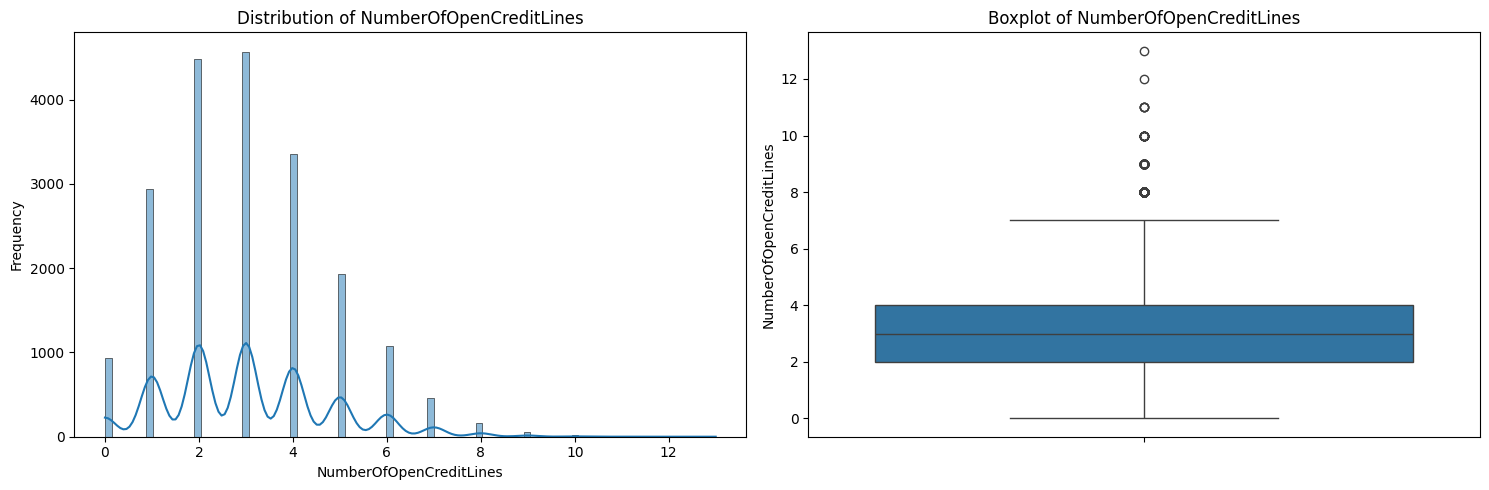

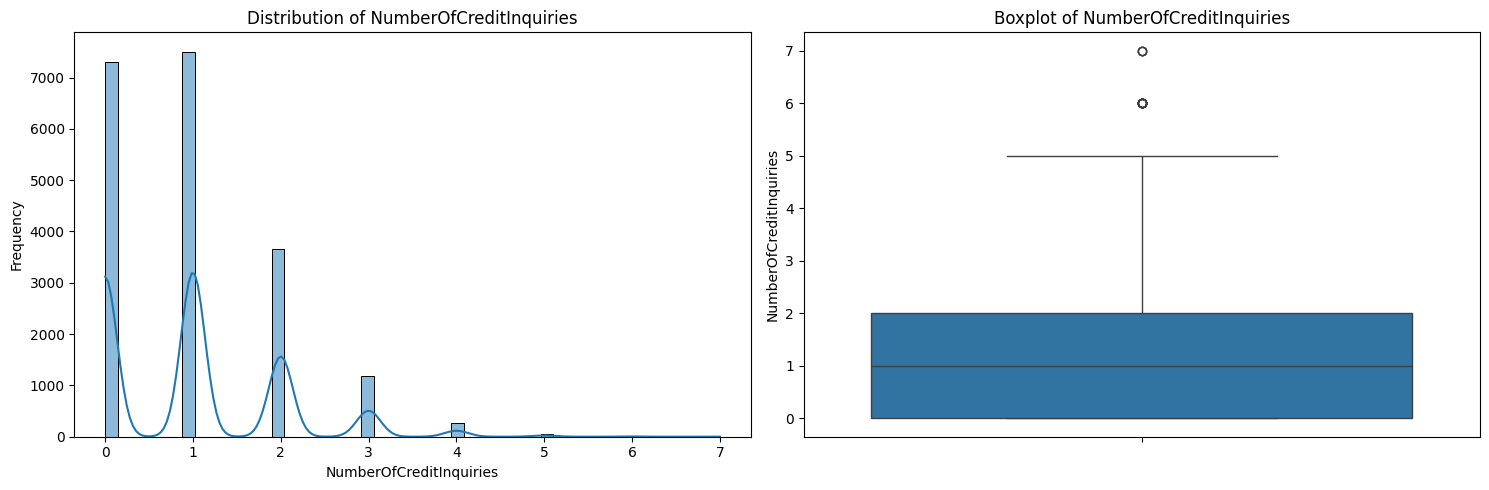

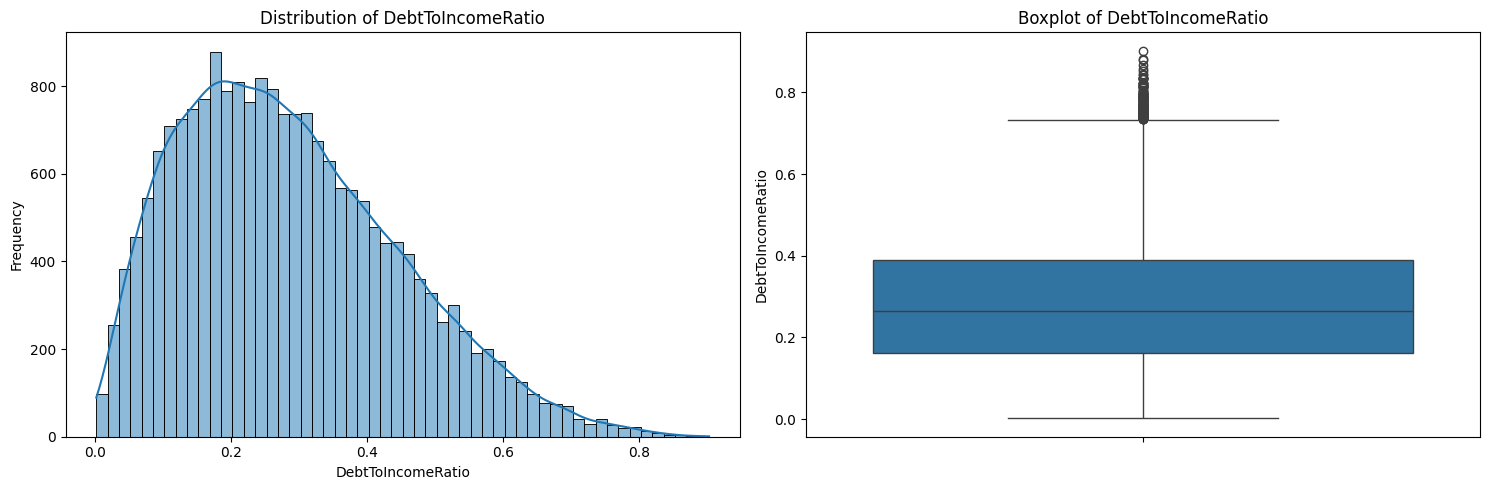

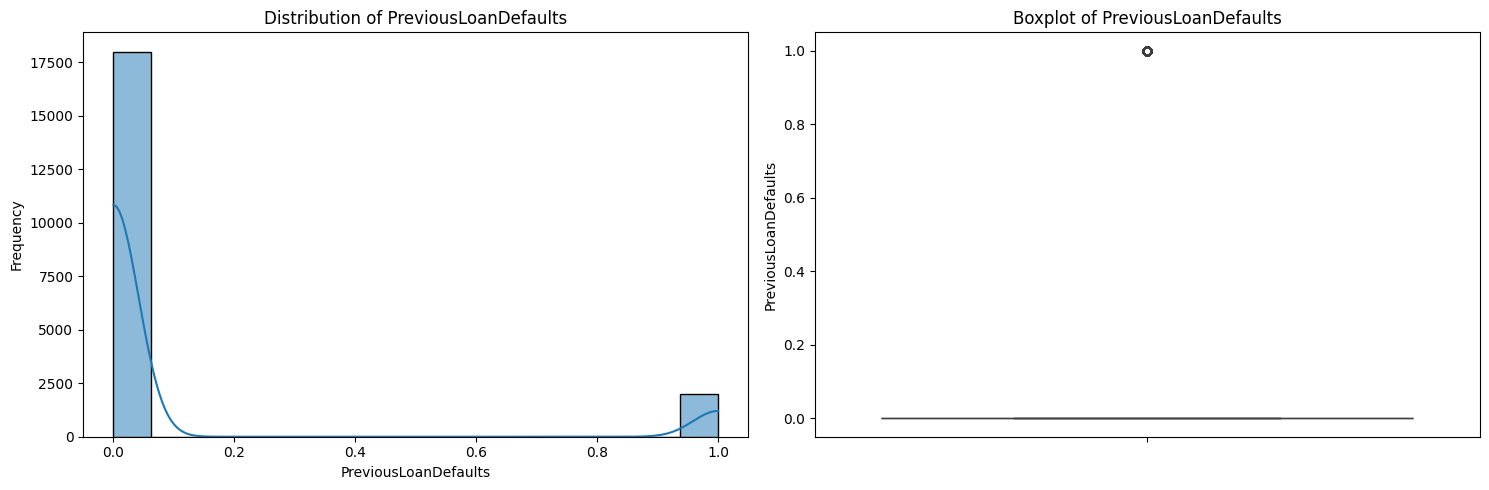

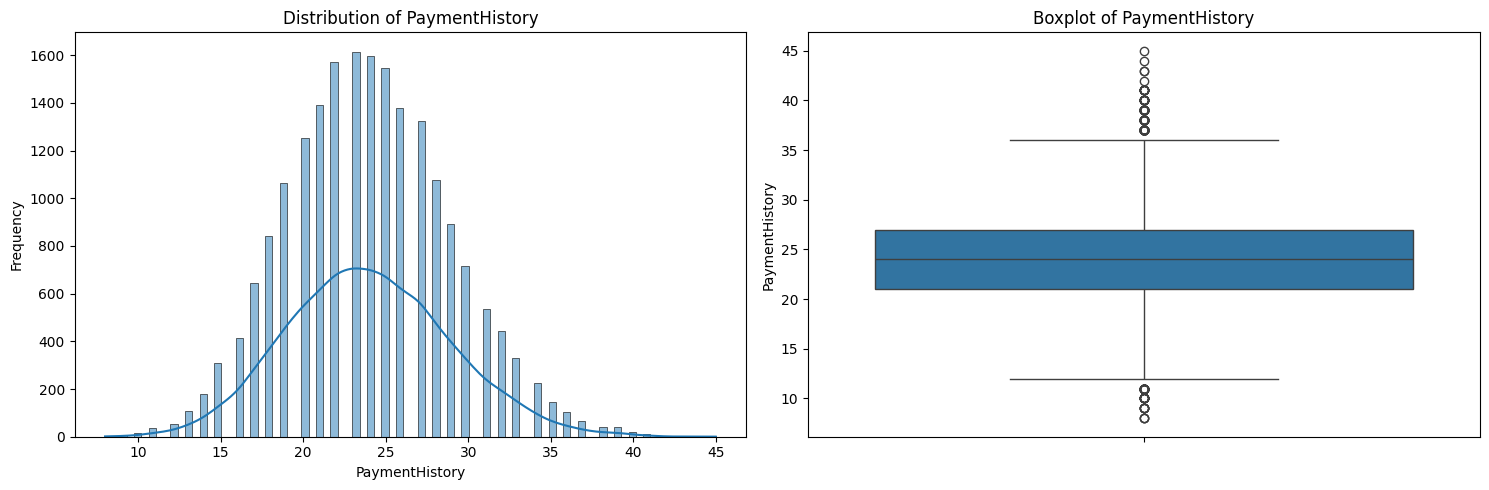

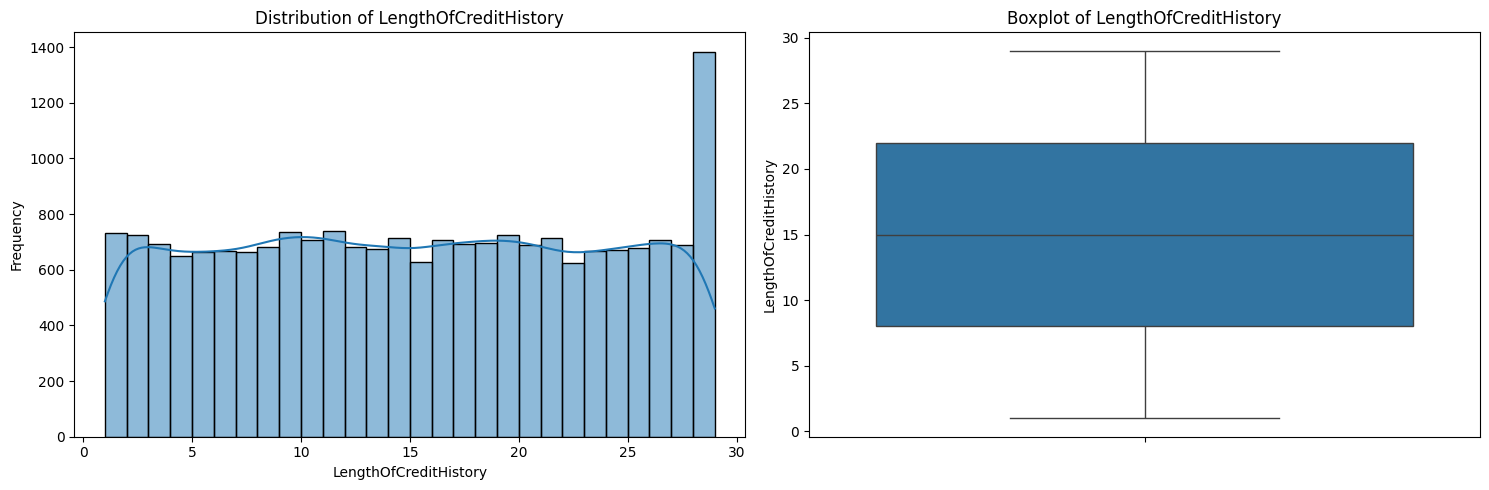

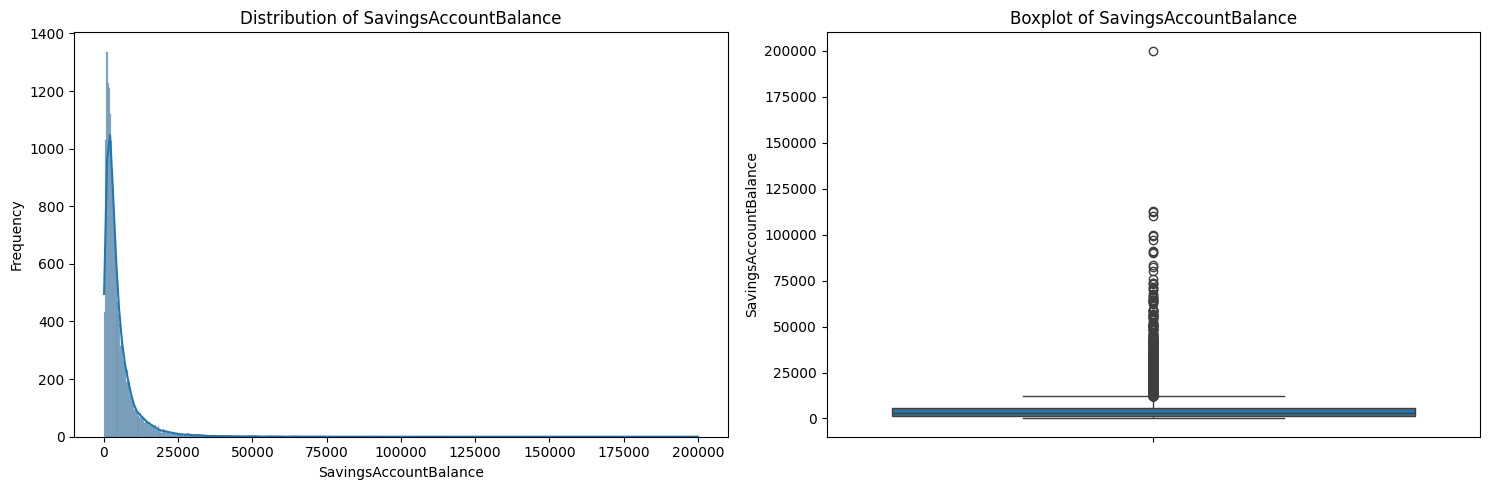

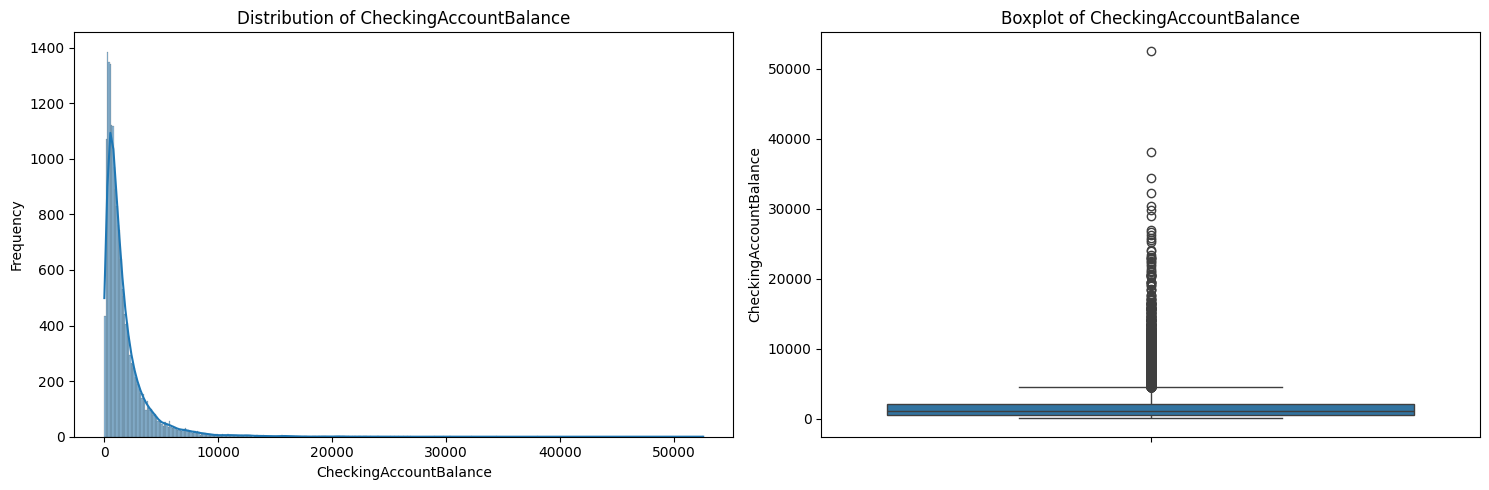

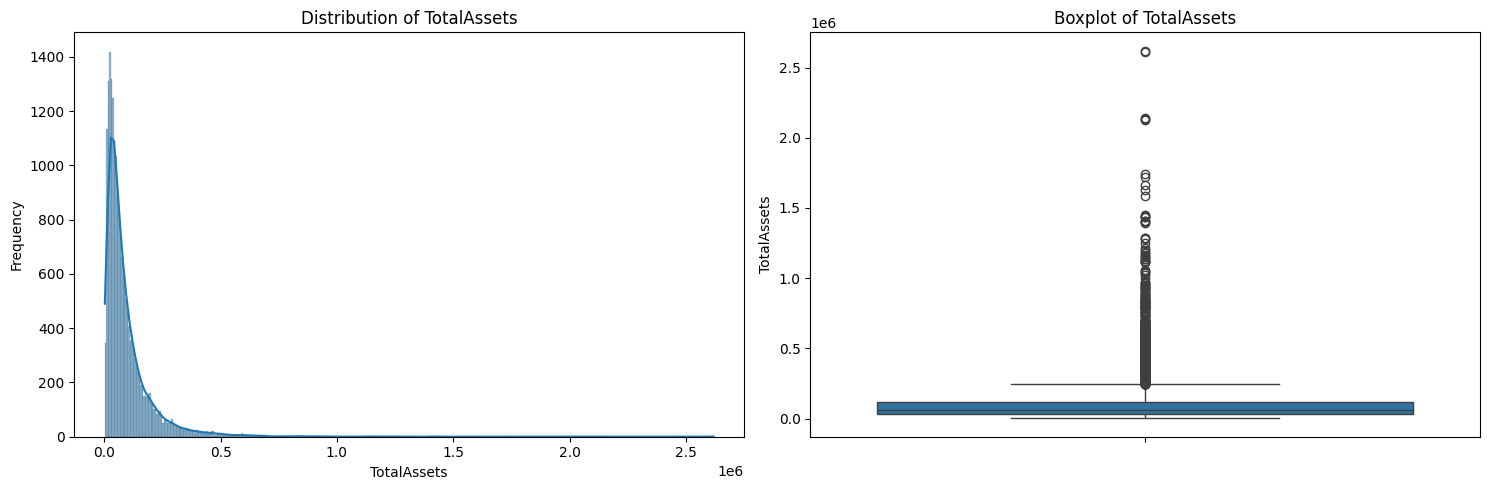

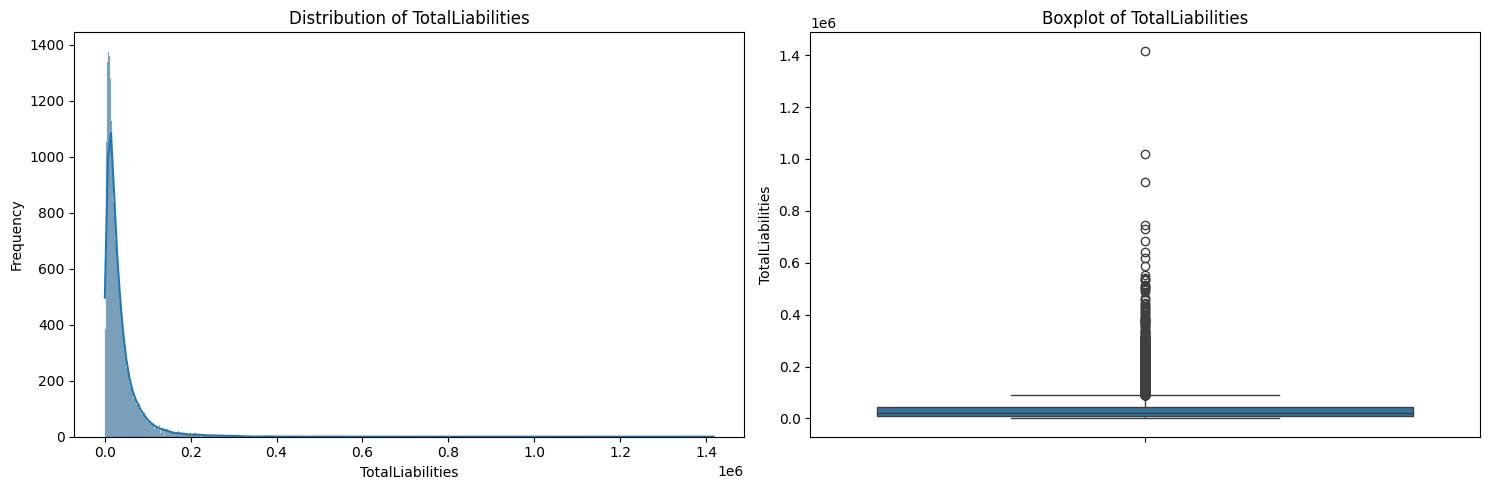

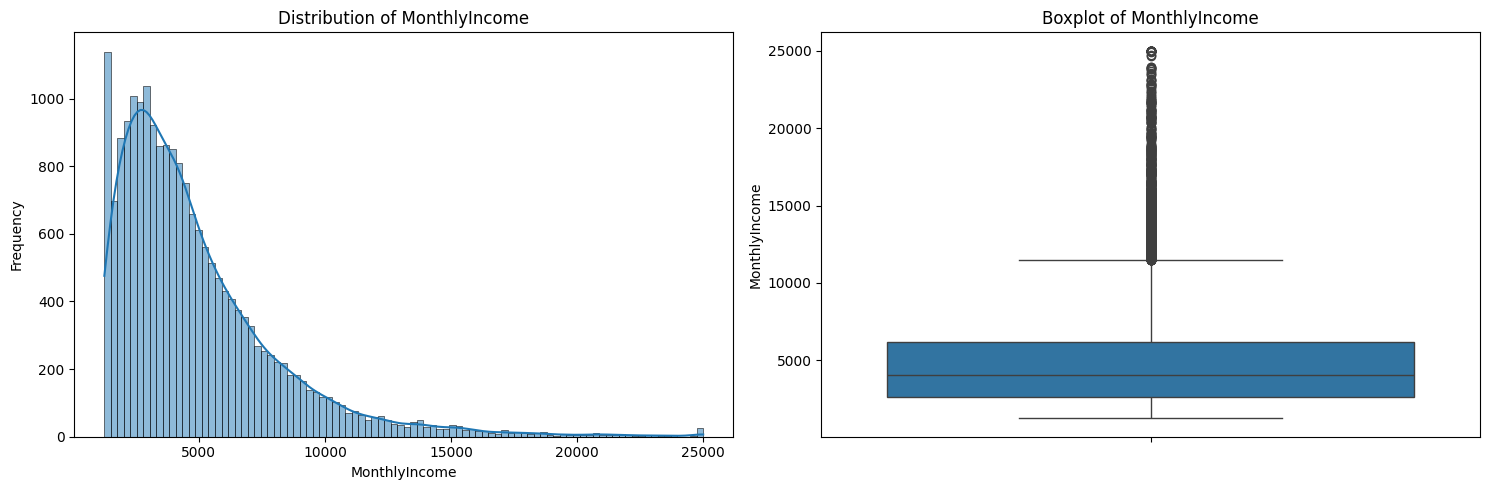

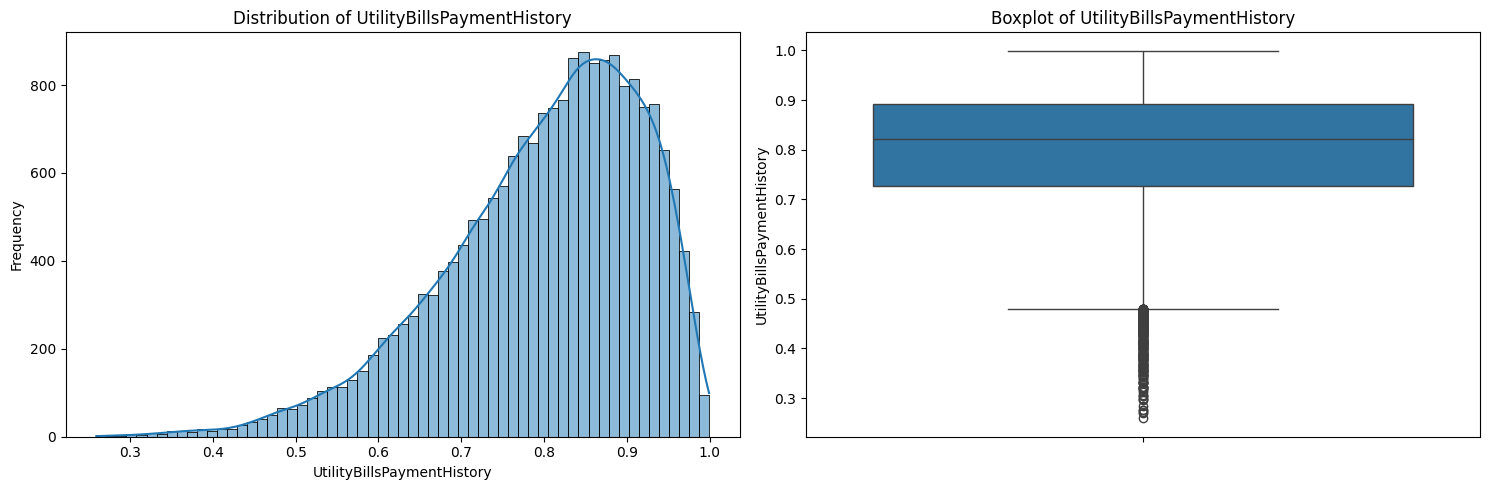

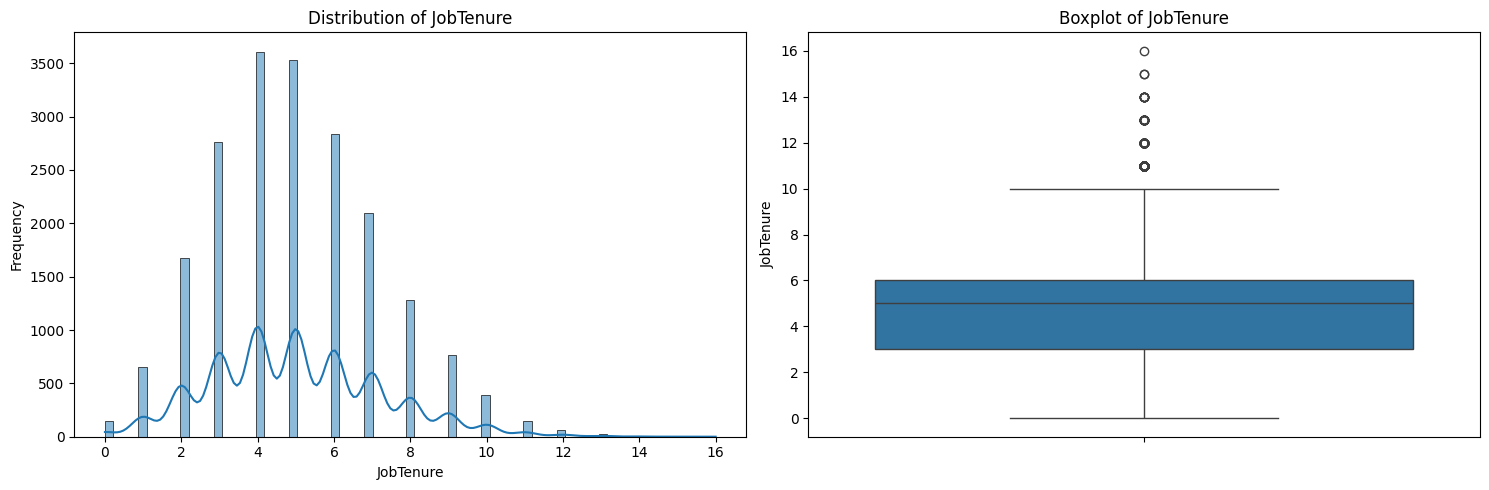

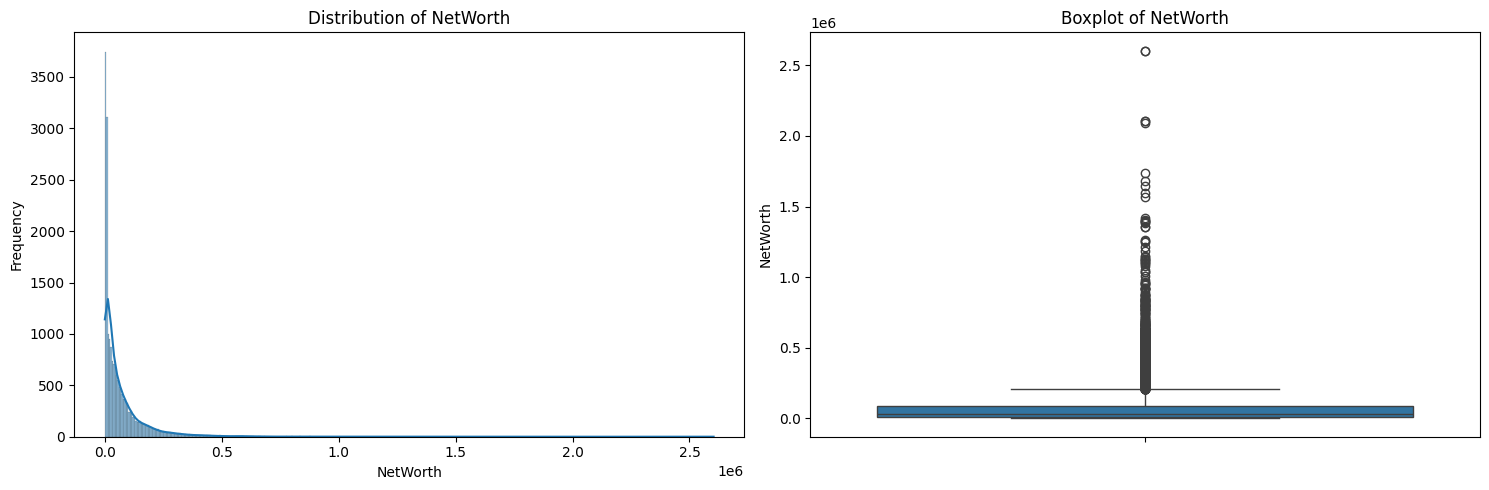

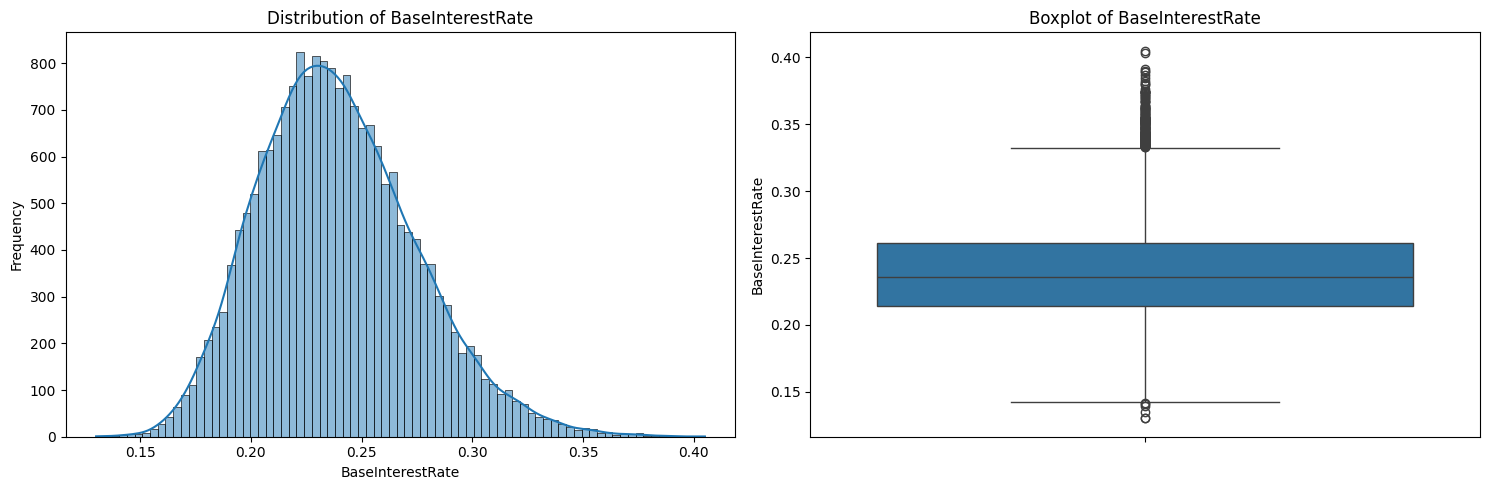

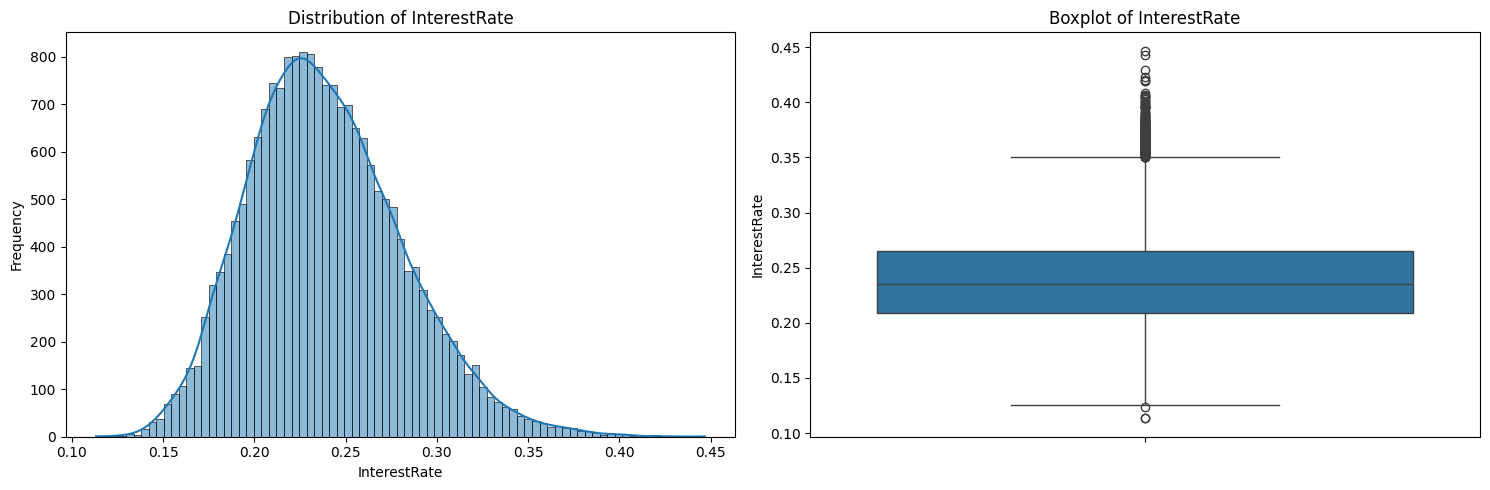

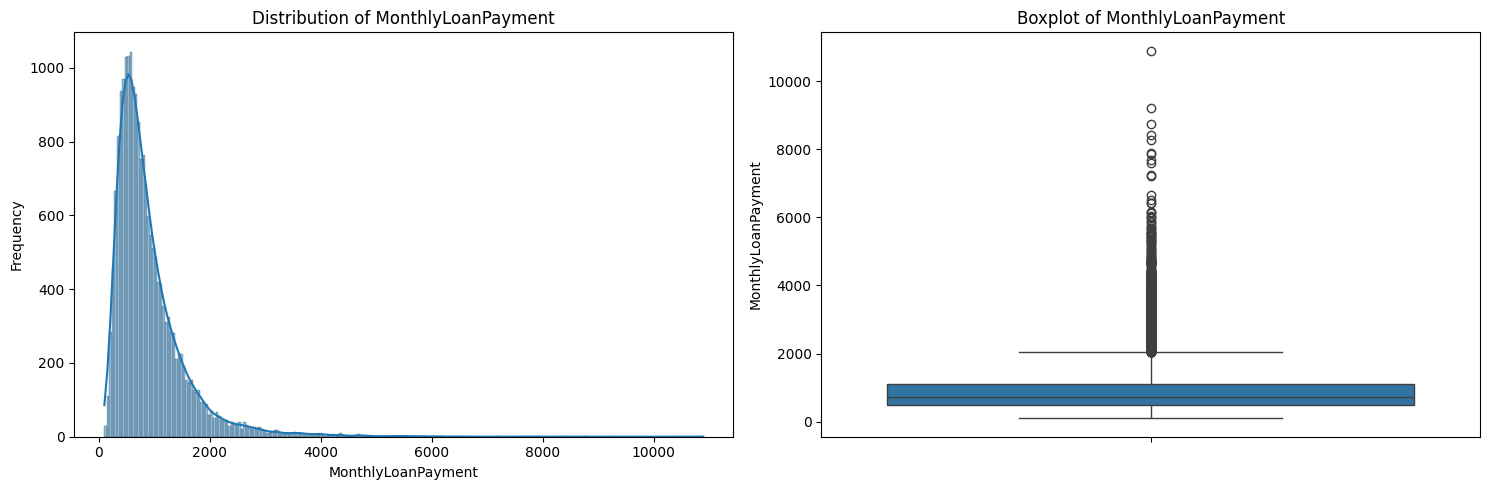

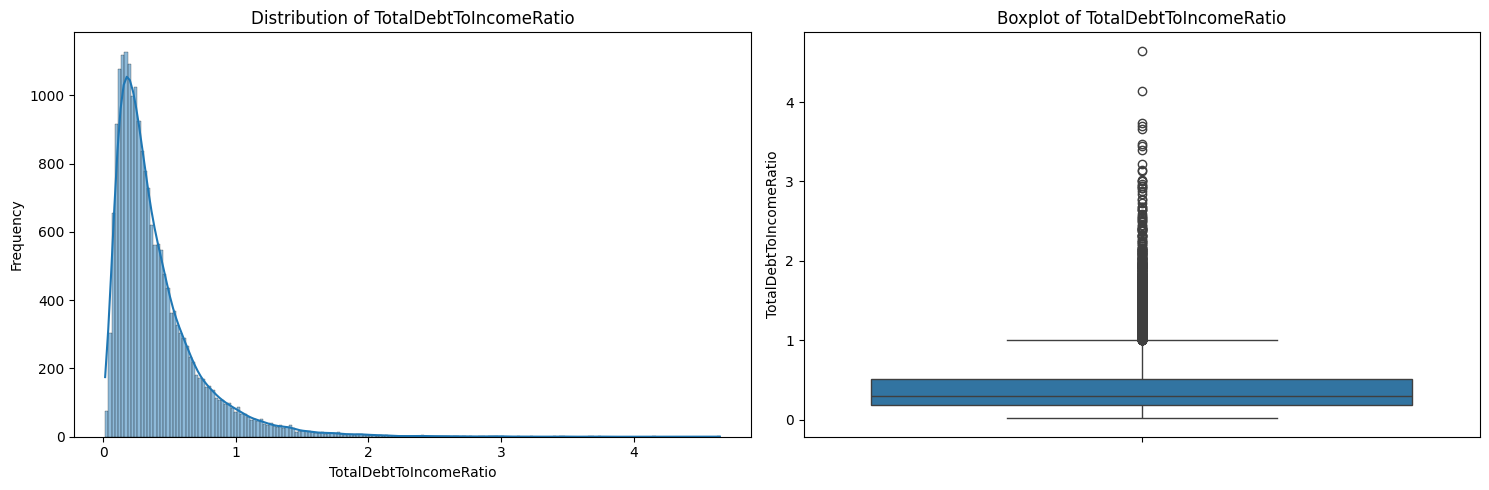

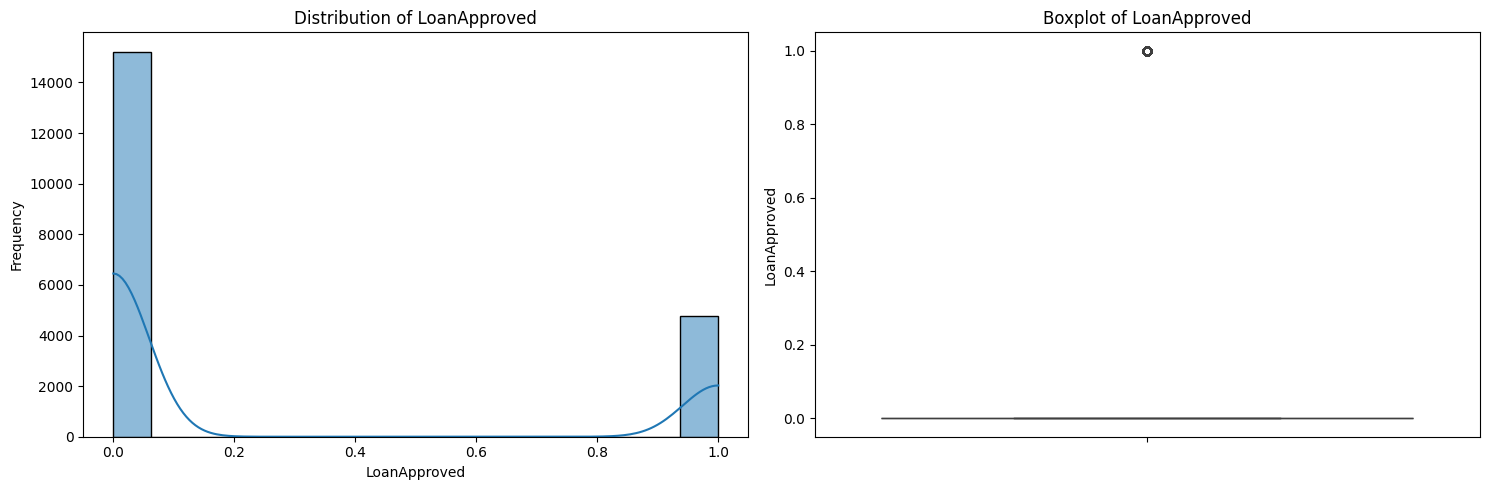

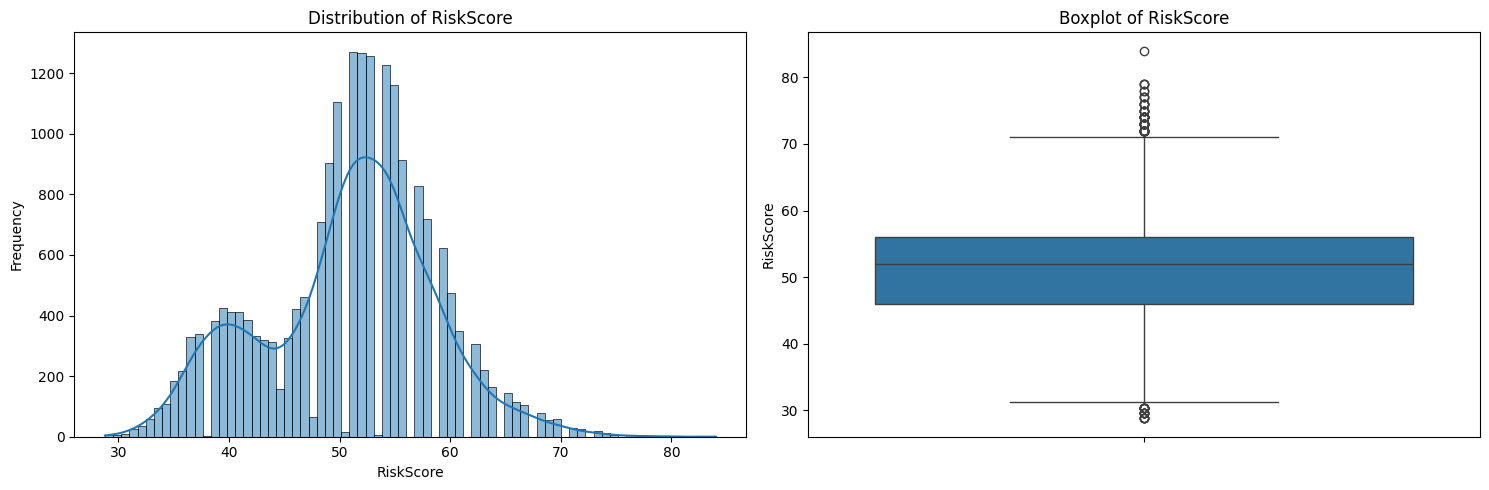

In [45]:
# Plot numerical distributions using histograms and boxplots
for feature in numerical_features:
    plt.figure(figsize=(15, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[feature].dropna(), kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[feature].dropna())
    plt.title(f'Boxplot of {feature}')
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

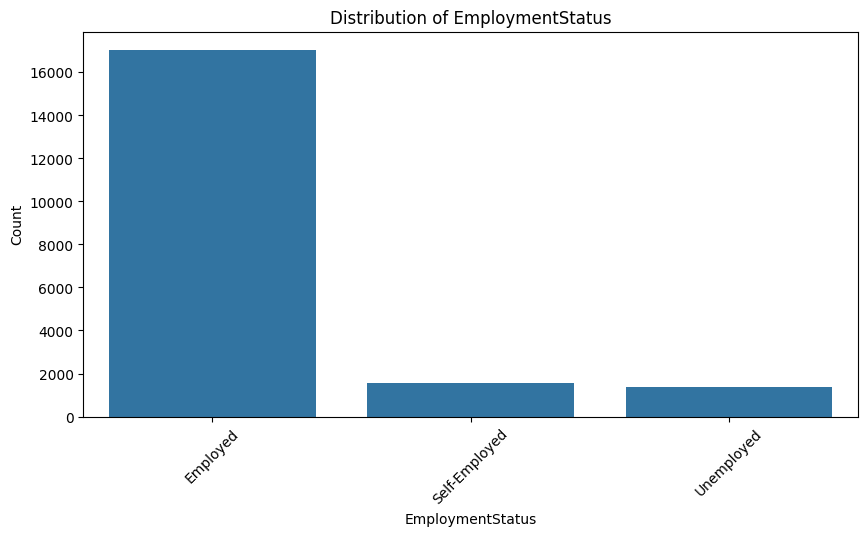

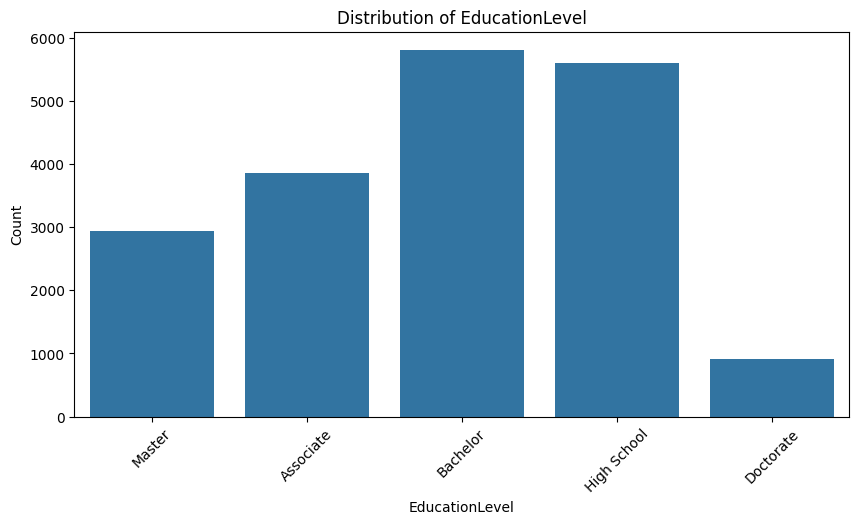

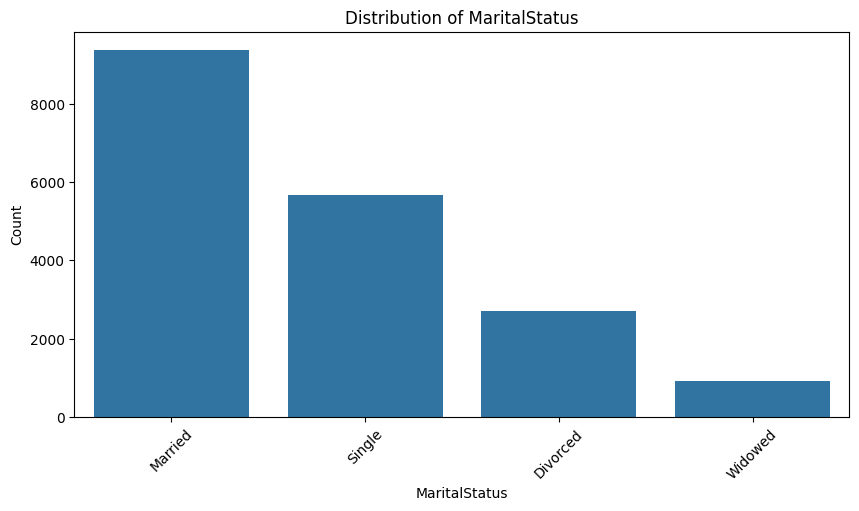

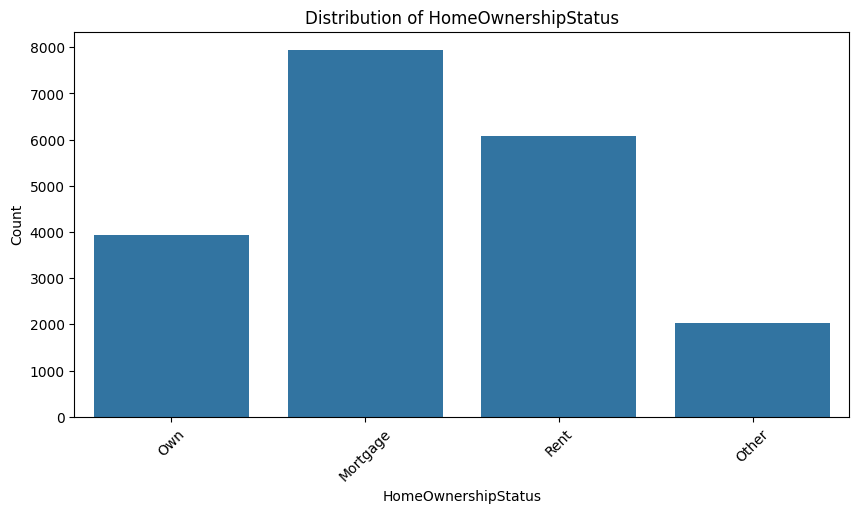

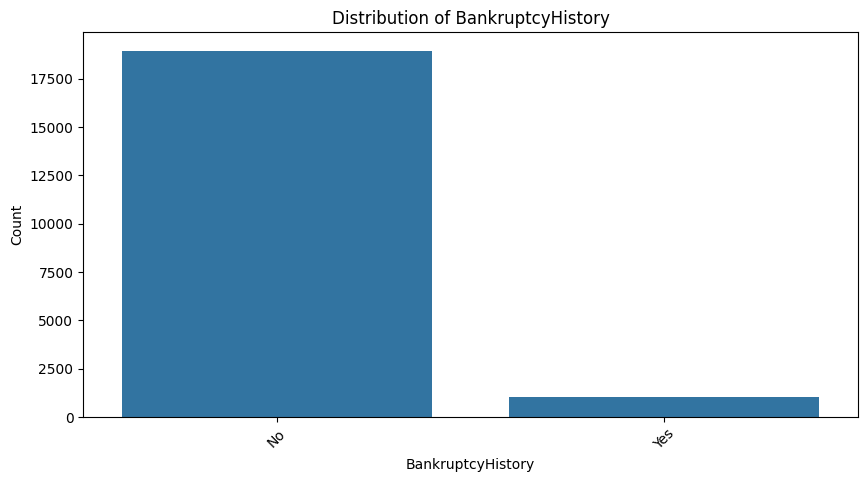

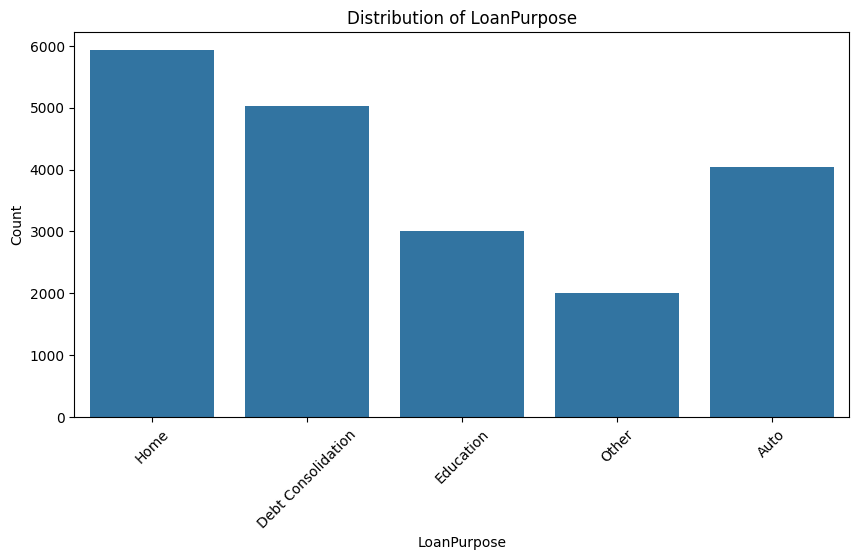

In [46]:
# Plot categorical distributions using count plots

for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=feature)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(
        feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

3.3 Investigate relationships between features

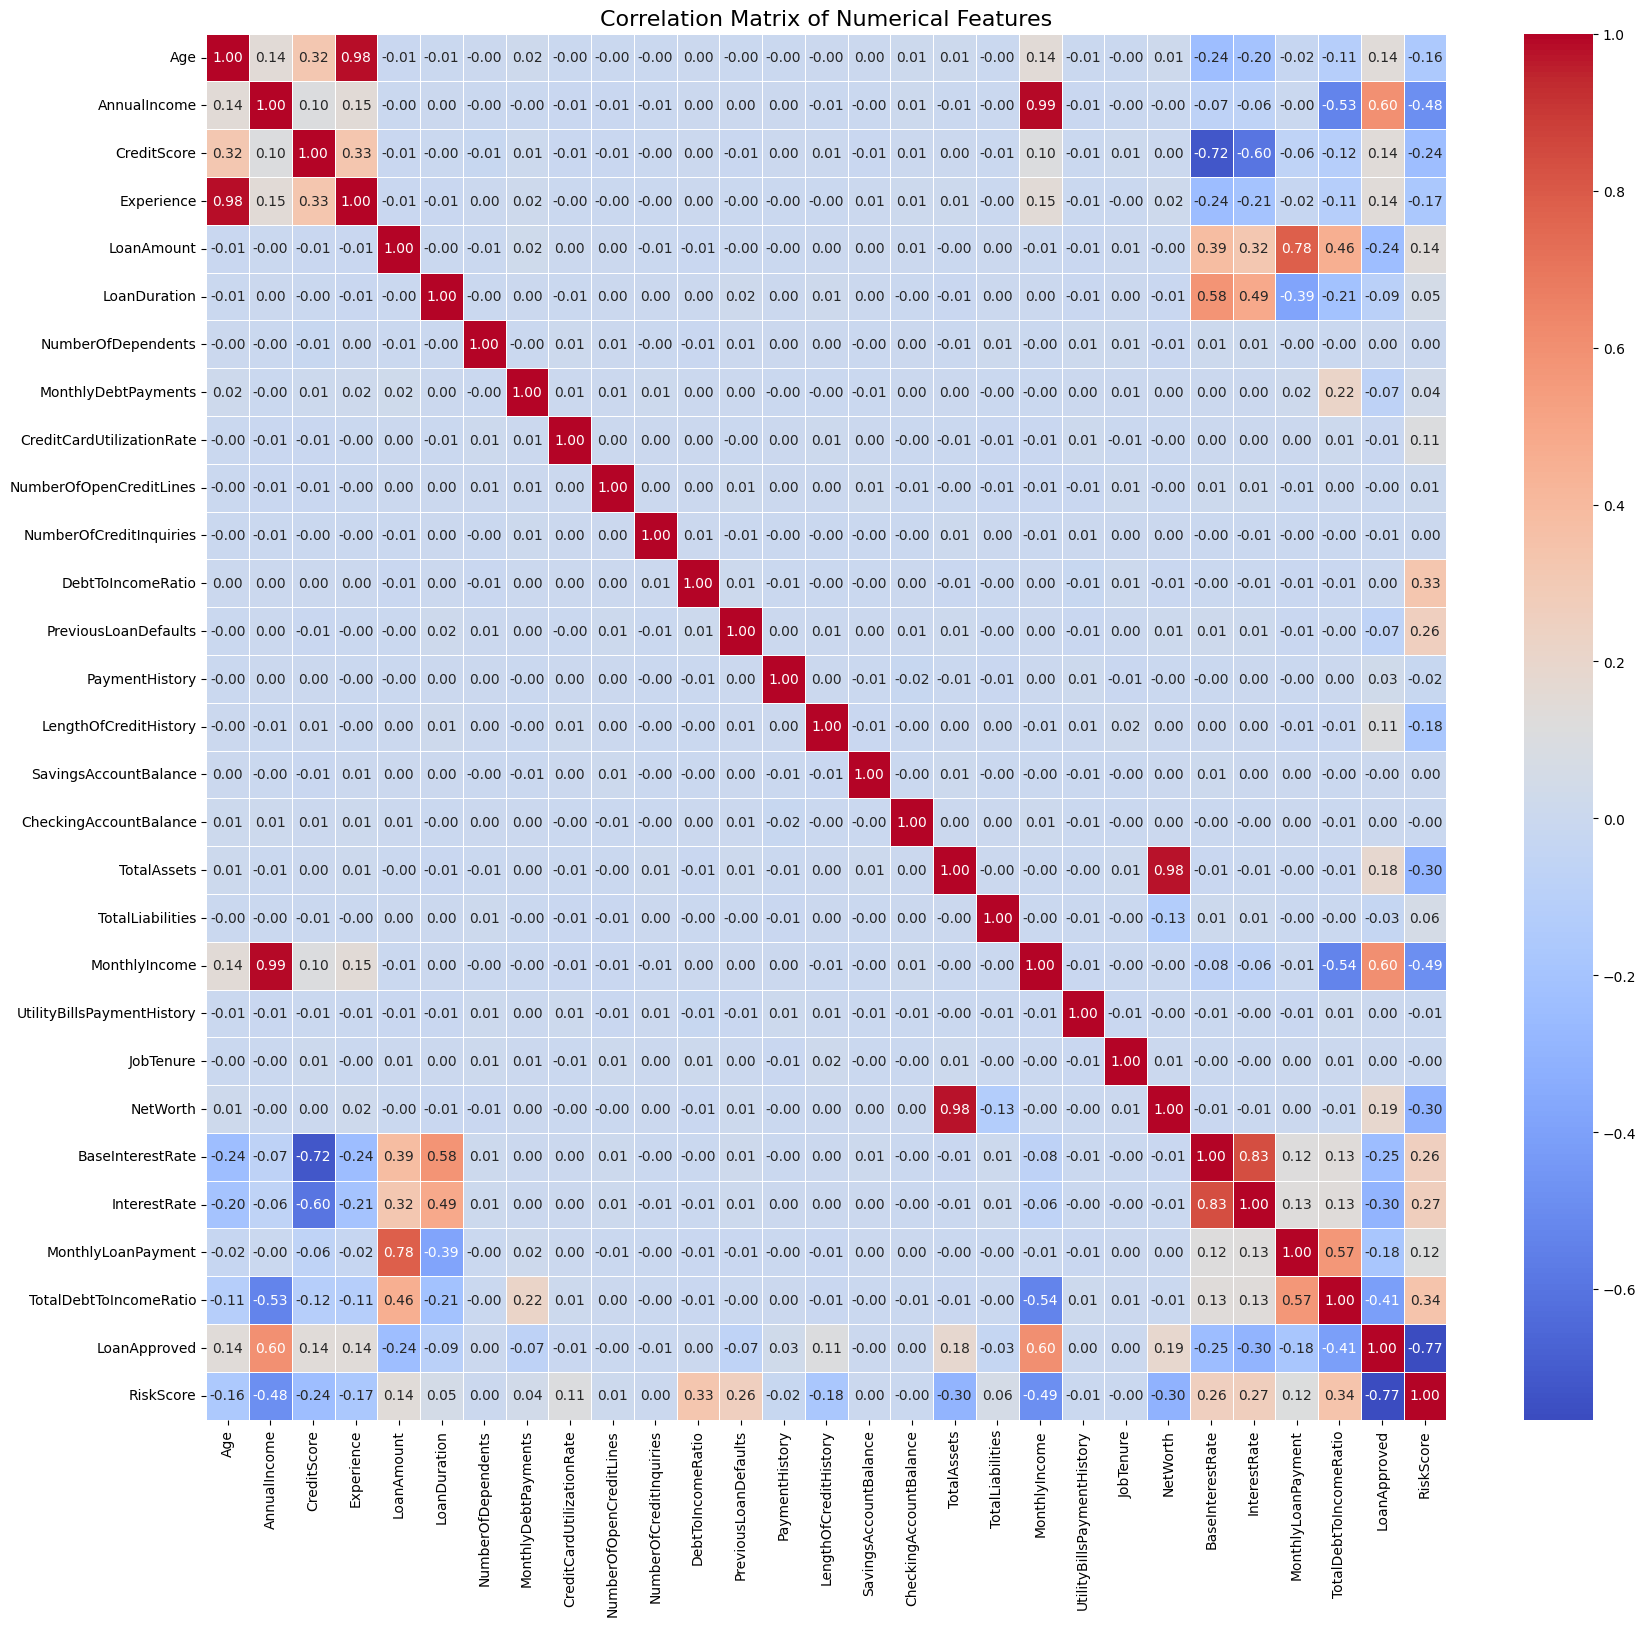

In [49]:
# Calculate Pearson correlation matrix for numeric columns
correlation_matrix = df[numerical_features].corr()

# Visualize the correlation matrix with a Heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

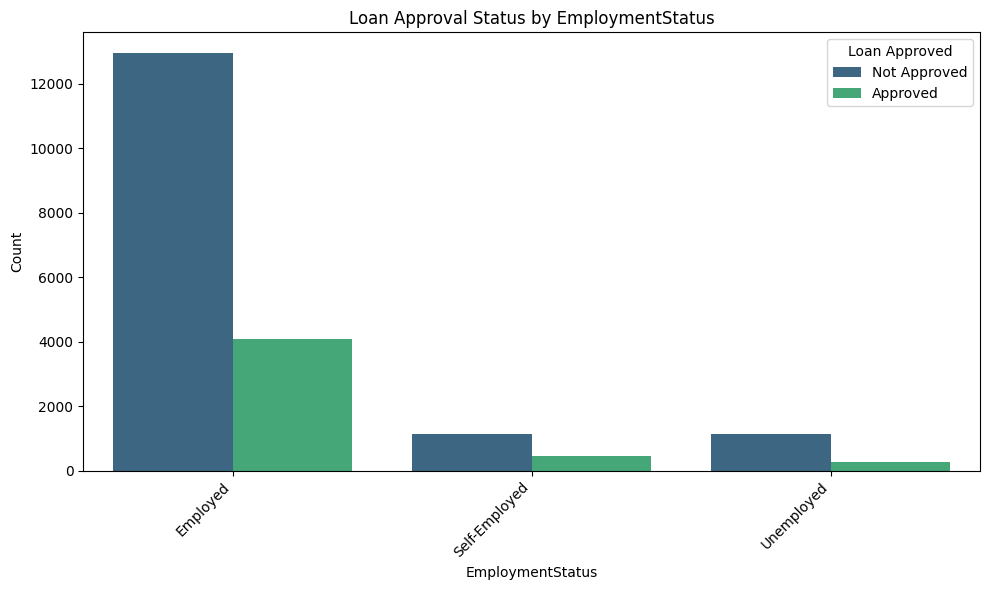

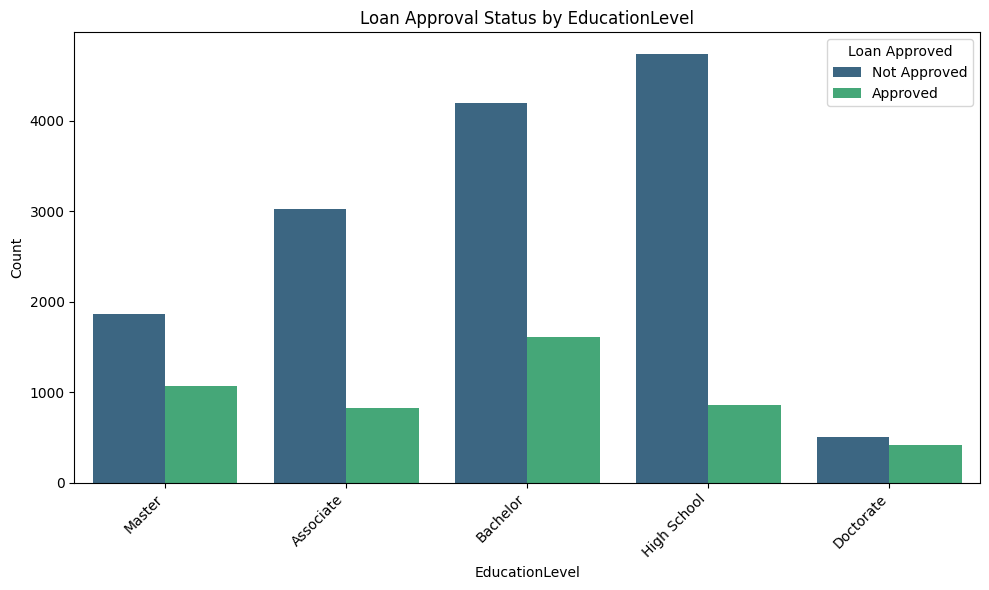

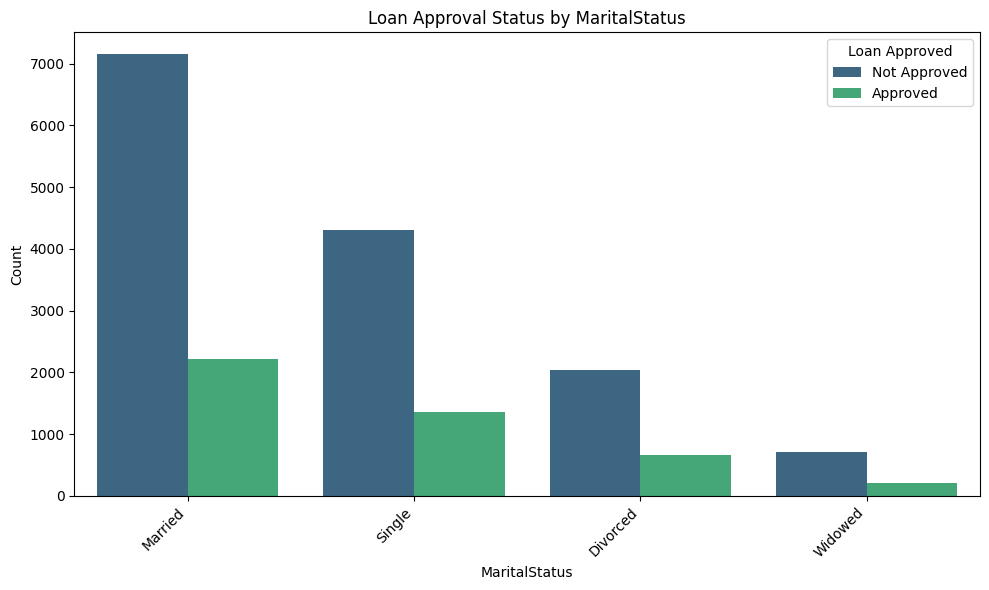

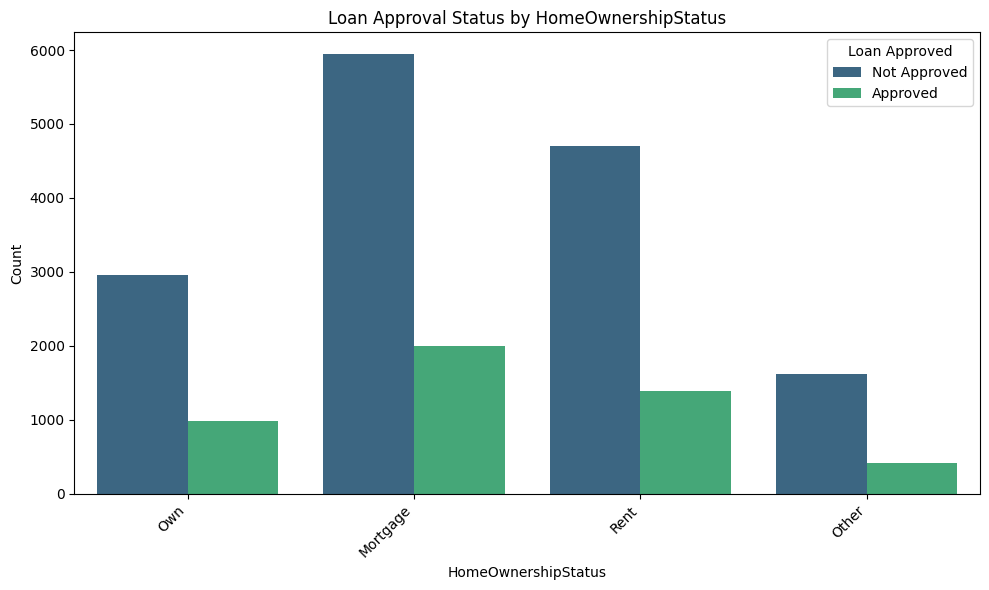

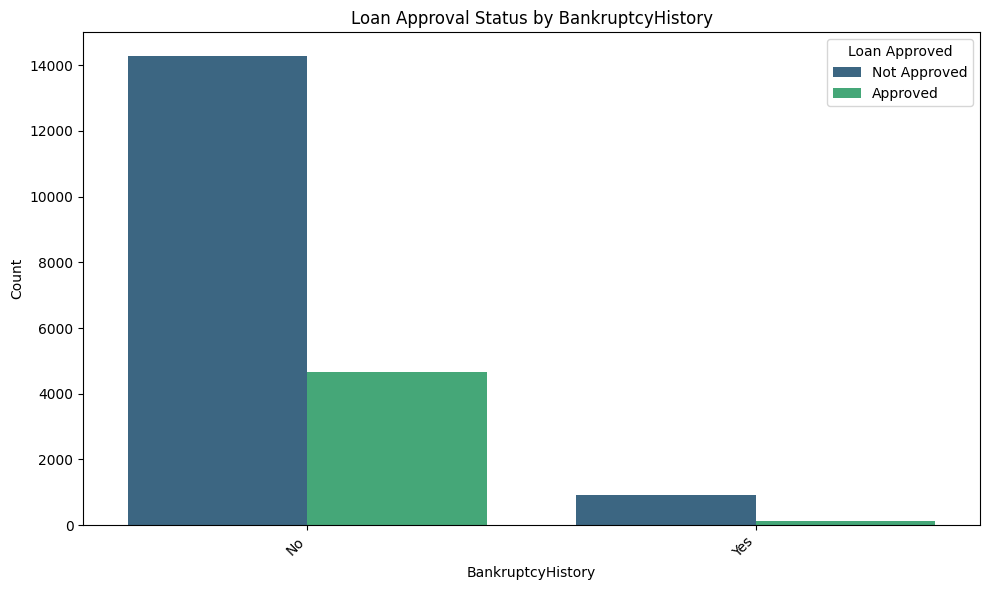

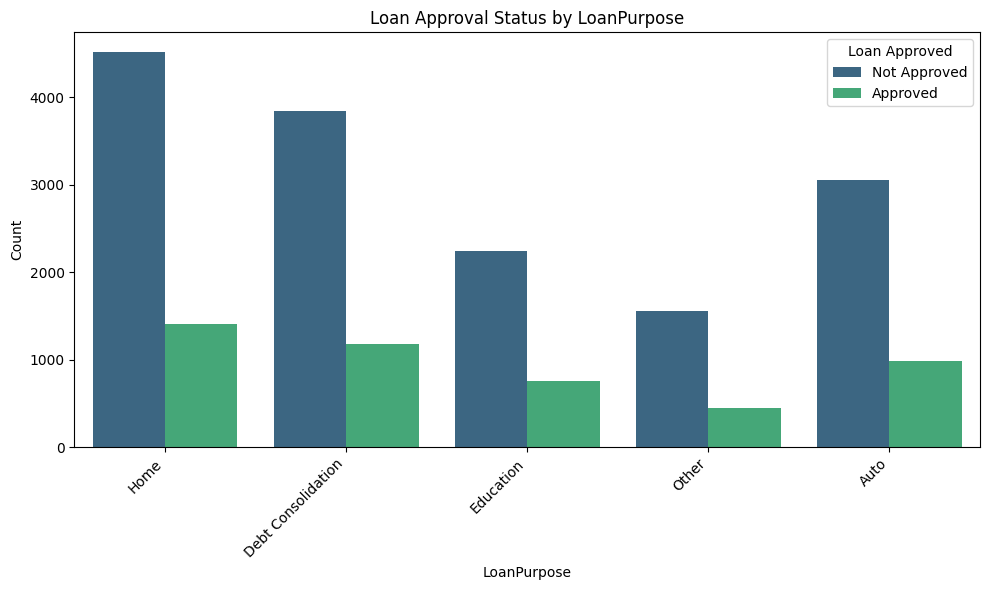

In [51]:
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=feature, hue='LoanApproved', palette='viridis')
    plt.title(f'Loan Approval Status by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Loan Approved', labels=['Not Approved', 'Approved'])
    plt.tight_layout()
    plt.show()

3.4 Create visualizations to help aid in EDA

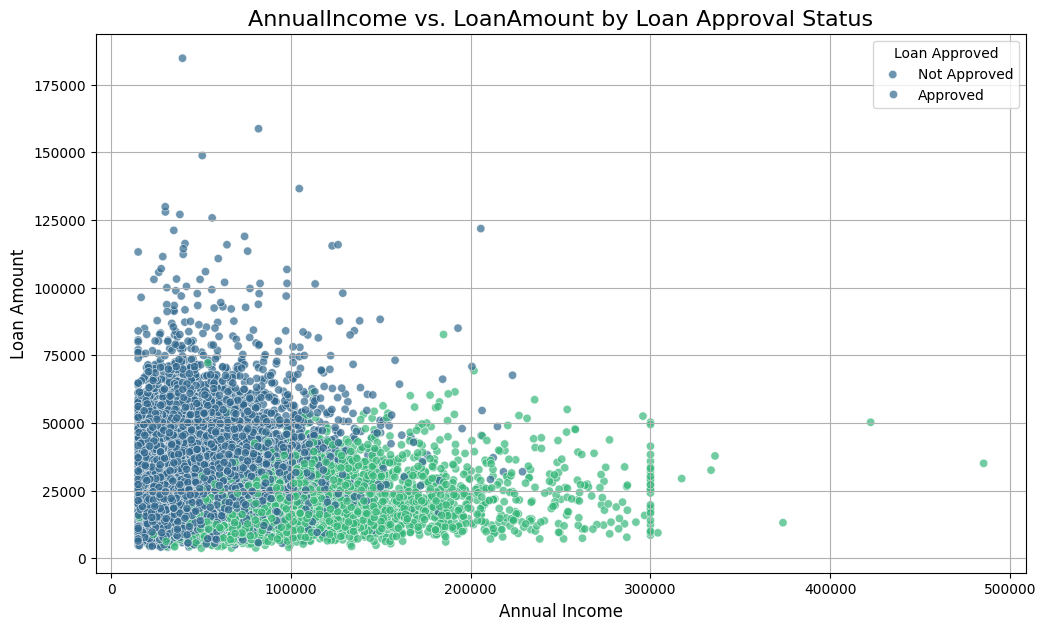

In [57]:
# Visualize relationship between AnnualIncome and LoanAmount, colored by LoanApproved
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='AnnualIncome', y='LoanAmount', hue='LoanApproved', palette='viridis', alpha=0.7)
plt.title('AnnualIncome vs. LoanAmount by Loan Approval Status', fontsize=16)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.legend(title='Loan Approved', labels=['Not Approved', 'Approved'])
plt.grid(True)
plt.show()

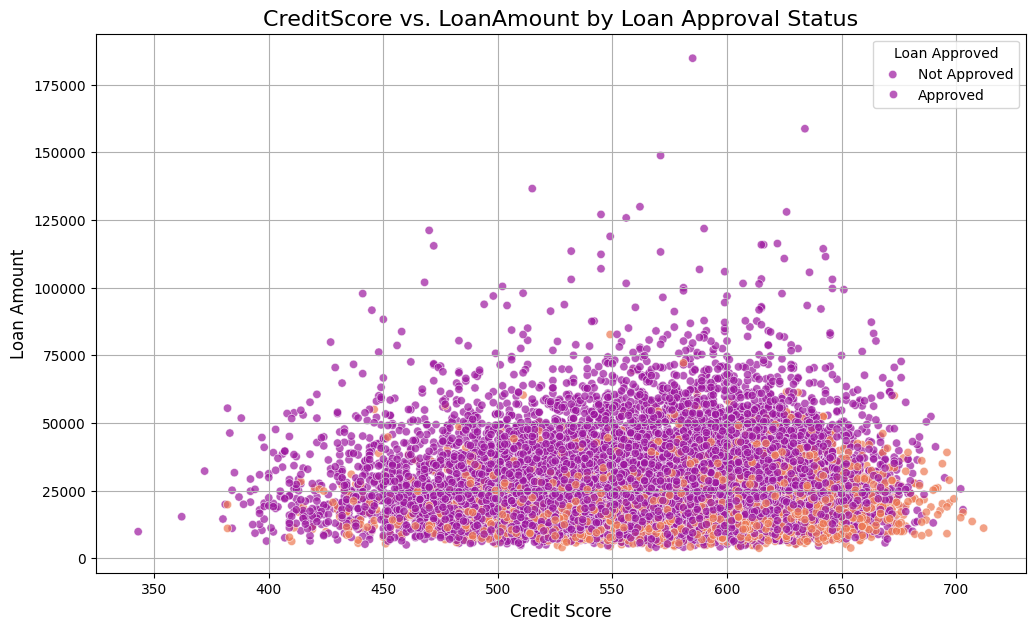

In [58]:
# Visualize relationship between CreditScore and LoanAmount, colored by LoanApproved
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='CreditScore', y='LoanAmount', hue='LoanApproved', palette='plasma', alpha=0.7)
plt.title('CreditScore vs. LoanAmount by Loan Approval Status', fontsize=16)
plt.xlabel('Credit Score', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.legend(title='Loan Approved', labels=['Not Approved', 'Approved'])
plt.grid(True)
plt.show()

3.5 Document potential data quality issues and their implications

In [62]:
# Summarize missing values and compute proportions
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100
missing_summary = pd.concat(
    [missing, missing_pct],
    axis=1,
    keys=['missing_count', 'missing_pct']
)

print("Missing values summary:")
print(missing_summary[missing_summary['missing_count'] > 0])

Missing values summary:
                       missing_count  missing_pct
MaritalStatus                   1331        6.655
EducationLevel                   901        4.505
SavingsAccountBalance            572        2.860


In [63]:
# Check for exact duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")


Duplicate rows found: 0


In [64]:
# Inspect categorical missing patterns and category counts
for col in categorical_features:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        print(f"\nCategorical column '{col}' has {missing_count} missing values.")
        print(df[col].value_counts(dropna=False).head())


Categorical column 'EducationLevel' has 901 missing values.
EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
Name: count, dtype: int64

Categorical column 'MaritalStatus' has 1331 missing values.
MaritalStatus
Married     9370
Single      5665
Divorced    2704
NaN         1331
Widowed      930
Name: count, dtype: int64


In [67]:
# Identify numeric columns with extreme values using the IQR method
numeric_check_columns = [col for col in numerical_features if col not in ['LoanApproved', 'RiskScore']]
outlier_info = []

for col in numeric_check_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    if len(outliers) > 0:
        outlier_info.append(
            (col, len(outliers), lower_bound, upper_bound, outliers.min(), outliers.max())
        )

print("\nPotential numeric outliers detected:")
for col, count, low, high, min_val, max_val in outlier_info:
    print(
        f"  - {col}: {count} values outside [{low:.2f}, {high:.2f}], "
        f"observed min {min_val}, max {max_val}"
    )


Potential numeric outliers detected:
  - Age: 64 values outside [8.00, 72.00], observed min 73, max 80
  - AnnualIncome: 947 values outside [-32389.00, 138459.00], observed min 138465.0, max 485341.0
  - CreditScore: 242 values outside [436.50, 712.50], observed min 343, max 436
  - Experience: 75 values outside [-15.00, 49.00], observed min 50, max 61
  - LoanAmount: 746 values outside [-7315.00, 53725.00], observed min 53737, max 184732
  - MonthlyDebtPayments: 744 values outside [-131.00, 981.00], observed min 982, max 2919
  - CreditCardUtilizationRate: 130 values outside [-0.18, 0.74], observed min 0.7354731680598023, max 0.9173800815542682
  - NumberOfOpenCreditLines: 249 values outside [-1.00, 7.00], observed min 8, max 13
  - NumberOfCreditInquiries: 16 values outside [-3.00, 5.00], observed min 6, max 7
  - DebtToIncomeRatio: 143 values outside [-0.18, 0.73], observed min 0.7345517661607368, max 0.9022526895282088
  - PreviousLoanDefaults: 2001 values outside [0.00, 0.00], ob

In [68]:
# Document quality issues and implications for modeling
print("\nData quality issues and implications:")
if missing_summary['missing_count'].sum() > 0:
    print("- Missing values exist and will need imputation or targeted handling.")
else:
    print("- No missing values detected across the dataset.")

if duplicates > 0:
    print("- Duplicate rows are present and should be removed or investigated.")
else:
    print("- No duplicate rows detected.")
print(
    "- Missing categorical values may indicate incomplete application fields and "
    "could bias the model if not handled carefully."
)
print(
    "- Outliers in numeric features may represent either legitimate extreme borrower "
    "profiles or data entry errors; they should be reviewed and possibly capped."
)
print(
    "- Some columns may require special preprocessing (for example, missing "
    "EducationLevel, MaritalStatus, and SavingsAccountBalance) to preserve signal "
    "without introducing bias."
)


Data quality issues and implications:
- Missing values exist and will need imputation or targeted handling.
- No duplicate rows detected.
- Missing categorical values may indicate incomplete application fields and could bias the model if not handled carefully.
- Outliers in numeric features may represent either legitimate extreme borrower profiles or data entry errors; they should be reviewed and possibly capped.
- Some columns may require special preprocessing (for example, missing EducationLevel, MaritalStatus, and SavingsAccountBalance) to preserve signal without introducing bias.


## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [ ]:
# Data Prep Code Here - Create New Cells As Needed
None

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune”


In [ ]:
#  Modeling Code Here - Create New Cells as Needed
None

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements